In [28]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(os.path.abspath("src"))
from wAMEs.temporal_dynamics import integrate_I_traj_kernel
from wAMEs.plotting import get_plot_style, make_truncated_colormap, apply_axis_style
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np

In [29]:
from wAMEs.core import load_group_statistics

# Load group statistics
network = "CNS"
gm, pn, mmax, nmax, pmax, state_meta = load_group_statistics(
    network,
    path="Data/group_statistics.txt",
)

nu = 9.5
mu = 1.0
w = 5.0
lam_kernel = 2e-3   # define here — currently missing, Cell 3 will NameError
scale = w           

# Output directory
save_dir = "Files"
os.makedirs(save_dir, exist_ok=True)

In [30]:
def w_allegiance(n, i, scale):
    """Nodes flee diverse groups — prefer homogeneous ones (allegiance/homophily).
    Rate peaks at phi=0.5 and is zero at the homogeneous extremes (phi=0 or 1)."""
    phi = i / n
    # print(f"n={n}, i={i}, phi={phi}, w_allegiance={scale * 4 * phi * (1 - phi)}")
    return scale * 4 * phi * (1 - phi)


Max trajectory deviation: 7.73e-01
Pass (atol=1e-10): False


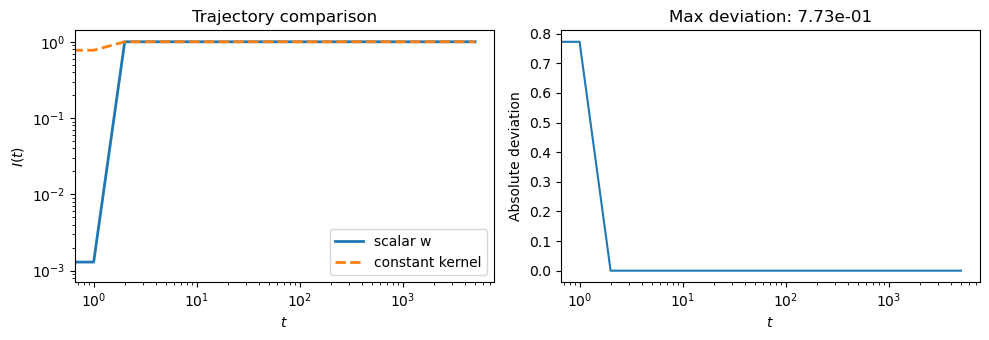

In [31]:
# --- Scalar limit verification ---
# A constant kernel w(n,i) = scale must reproduce integrate_I_traj exactly.
# Max deviation at machine precision (~1e-14) confirms S_w is correct.
# Larger deviation means the pnmat weighting in S_w is wrong.

from wAMEs.temporal_dynamics import integrate_I_traj

test_I0 = 1e-3
test_lam = lam_kernel  # 2e-3
test_traj_points = 5000  # coarse — just need trajectory shape, not resolution

# Scalar baseline
t_scalar, I_scalar = integrate_I_traj(
    lam=test_lam,
    state_meta=state_meta,
    nmax=nmax,
    mmax=mmax,
    gm=gm,
    mu=mu,
    w=scale,       # w=5.0, same as scale
    nu=nu,
    I0=test_I0,
    traj_points=test_traj_points,
)

# Constant kernel — should be identical if S_w reduces correctly to I
t_kernel, I_kernel, fni_kernel = integrate_I_traj_kernel(
    lam=test_lam,
    w_func=lambda n, i, s: s,   # constant: w(n,i) = scale
    w_args=(scale,),
    state_meta=state_meta,
    nmax=nmax,
    mmax=mmax,
    gm=gm,
    mu=mu,
    nu=nu,
    I0=test_I0,
    traj_points=test_traj_points,
)

max_dev = np.max(np.abs(I_scalar - I_kernel))
print(f"Max trajectory deviation: {max_dev:.2e}")
print(f"Pass (atol=1e-10): {np.allclose(I_scalar, I_kernel, atol=1e-10)}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(t_scalar, I_scalar, label="scalar w", lw=2)
axes[0].plot(t_kernel, I_kernel, "--", label="constant kernel", lw=2)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$t$")
axes[0].set_ylabel(r"$I(t)$")
axes[0].set_title("Trajectory comparison")
axes[0].legend()

axes[1].plot(t_scalar, np.abs(I_scalar - I_kernel))
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$t$")
axes[1].set_ylabel("Absolute deviation")
axes[1].set_title(f"Max deviation: {max_dev:.2e}")

plt.tight_layout()
plt.show()

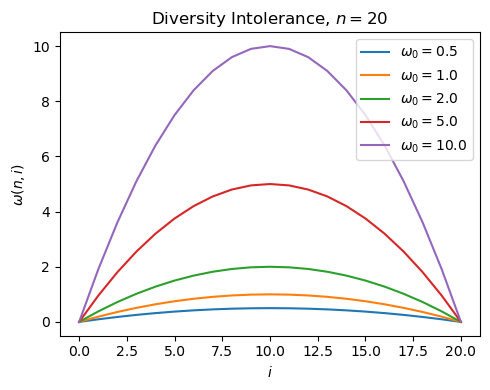

In [32]:
n = nmax  # e.g. nmax for Thiers13
i_vals = np.arange(0, n+1)
scales = [0.5, 1.0, 2.0, 5.0, 10.0]

fig, ax = plt.subplots(figsize=(5, 4))

for scale in scales:
    w_vals = [w_allegiance(n, i, scale) for i in i_vals]
    ax.plot(i_vals, w_vals, label=rf"$\omega_0={scale}$")

ax.set_xlabel(r"$i$")
ax.set_ylabel(r"$\omega(n,i)$")
ax.set_title(rf"Diversity Intolerance, $n={n}$")
ax.legend()
plt.tight_layout()
plt.savefig("src/wAMEs/figures/allegiance_kernel.png", dpi=300)
plt.show()

Running trajectory integration with allegiance kernel (scale=5.0)...


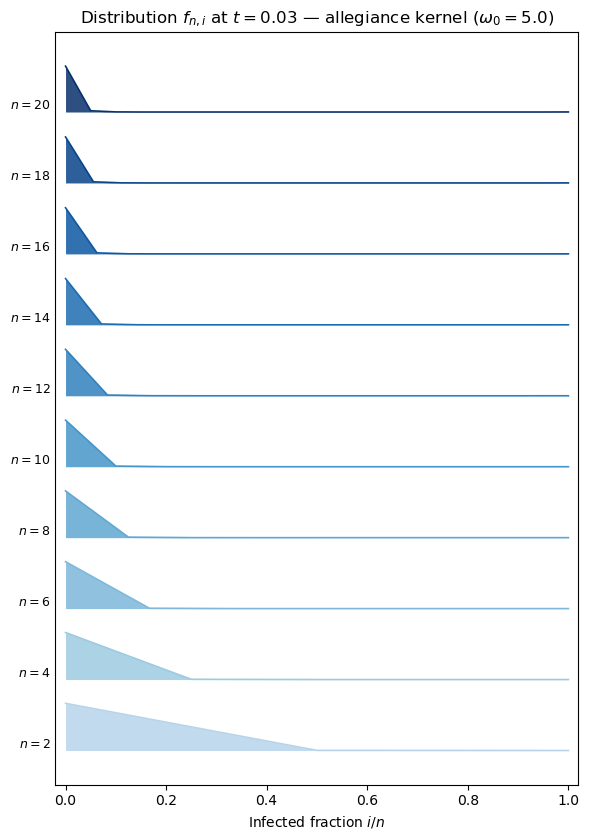

In [33]:
# Distribution of group states across n values at a single time snapshot
# Ridgeline style matching example_dist.png
I0 = 1e-3
traj_points = 5000
t_max = 20.0
scale = 5.0  # w=5.0, same as scale
print(f"Running trajectory integration with allegiance kernel (scale={scale})...")
t_all, I_all, fni_traj = integrate_I_traj_kernel(
    lam=lam_kernel,
    w_func=w_allegiance,
    w_args=(scale,),
    state_meta=state_meta,
    nmax=nmax,
    mmax=mmax,
    gm=gm,
    mu=mu,
    nu=nu,
    I0=I0,
    traj_points=traj_points,
    t_max=t_max,
)

# Pick a snapshot — change index to explore different moments in the transient
log_snaps = np.logspace(np.log10(t_all[1]), np.log10(t_all[-1]), 5)
snap_indices = [np.argmin(np.abs(t_all - ts)) for ts in log_snaps]
tidx = snap_indices[1]   # middle snapshot is 2; try [1] or [3]
t_snap = t_all[tidx]

# n values to display — every other size from 2 to nmax
n_show = list(range(2, nmax + 1, max(1, nmax // 8)))
if nmax not in n_show:
    n_show.append(nmax)
n_show = sorted(n_show)

spacing = 1.5
cmap = plt.get_cmap("Blues")
colors = [cmap(0.3 + 0.7 * k / max(len(n_show) - 1, 1)) for k in range(len(n_show))]

fig, ax = plt.subplots(figsize=(6, len(n_show) * 0.7 + 1.5))

for k, n0 in enumerate(n_show):
    phi_vals = np.arange(n0 + 1) / n0
    dist = fni_traj[tidx, n0, :n0 + 1].copy()
    total = dist.sum()
    if total > 1e-14:
        dist /= total
    baseline = k * spacing
    ax.fill_between(phi_vals, baseline, baseline + dist,
                    alpha=0.85, color=colors[k], linewidth=0)
    ax.plot(phi_vals, baseline + dist, color=colors[k], lw=1.2)
    ax.text(-0.03, baseline, rf"$n={n0}$", ha="right", va="bottom", fontsize=9)

ax.set_xlabel(r"Infected fraction $i/n$")
ax.set_yticks([])
ax.set_xlim(-0.02, 1.02)
ax.set_title(rf"Distribution $f_{{n,i}}$ at $t={t_snap:.2f}$ — allegiance kernel ($\omega_0={scale}$)")
plt.tight_layout()
plt.savefig("src/wAMEs/figures/group_state_ridgeline.png", dpi=300)
plt.show()

Sweep complete.
--- Localization diagnostics (scale=10) ---
Scalar  lam_c = 1.000e-06   lam* = 1.073e-06   localized = True
Kernel  lam_c = 4.095e-06   lam* = 1.073e-06   localized = False
Allegiance shifts lam* by factor 1.00x relative to scalar


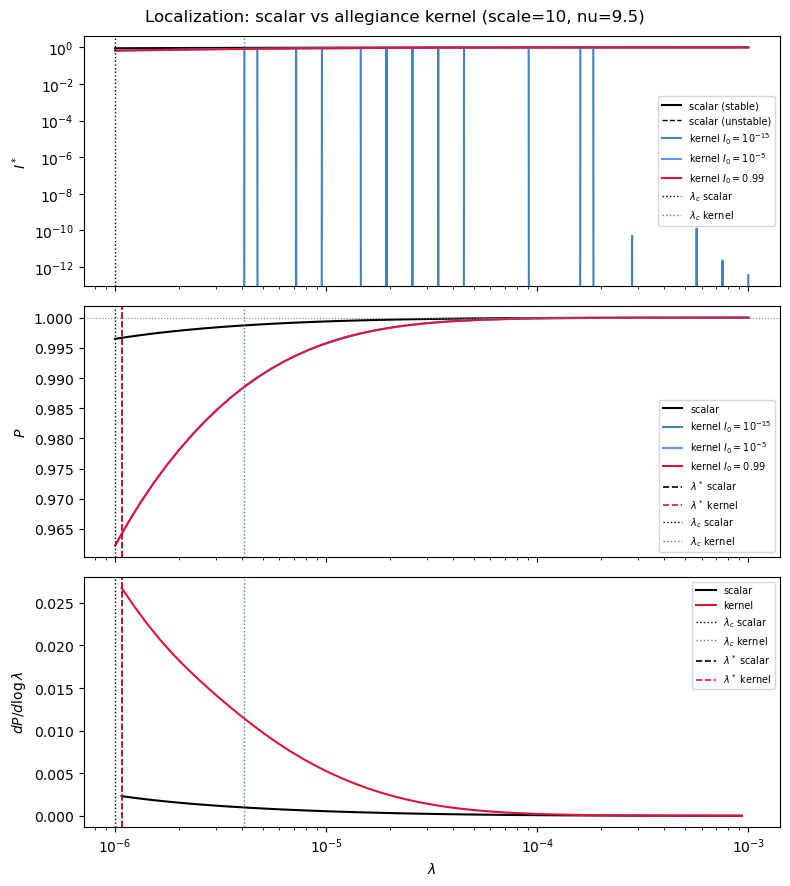

In [34]:
# Lambda sweep: compare localization P(λ) for allegiance kernel vs. scalar-w baseline
from wAMEs.core import build_inf_mat, compute_In_from_fni, y4_tilde, normalize_group_distribution
from wAMEs.fixed_points import collect_fixed_points_by_lam, pack_per_lam_pts

scale = 10   # pin — cell 25097866 ends with scale=10.0 as a loop side-effect

lam_vals = np.logspace(-6, -3, 50)
pn_filtered = normalize_group_distribution(pn)
m_arr = state_meta[2]

traj_points_ss = 500
t_max_ss = 400.0

# --- Non-kernel baseline: analytical fixed points ---
r_max = lam_vals[-1] * nmax**nu * 10
per_lam_scalar = collect_fixed_points_by_lam(
    lam_vals=lam_vals,
    nu=nu,
    nmax=nmax,
    mu=mu,
    w=scale,
    state_meta=state_meta,
    m_arr=m_arr,
    gm=gm,
    pn_filtered=pn_filtered,
    r_min=1e-8,
    r_max=r_max,
    n_grid_root=500,
)
I_scalar, P_scalar, stable_scalar = pack_per_lam_pts(per_lam_scalar, lam_vals)

# --- Kernel: three ICs to expose bistable window ---
I0_vals = [1e-15, 1e-5, 0.99]
labels  = [r'kernel $I_0=10^{-15}$', r'kernel $I_0=10^{-5}$', r'kernel $I_0=0.99$']
clrs    = ['steelblue', 'cornflowerblue', 'crimson']

I_ker = {I0: np.full(len(lam_vals), np.nan) for I0 in I0_vals}
P_ker = {I0: np.full(len(lam_vals), np.nan) for I0 in I0_vals}

for j, lam in enumerate(lam_vals):
    for I0 in I0_vals:
        try:
            _, I_traj, fni_traj = integrate_I_traj_kernel(
                lam=lam,
                w_func=w_allegiance,
                w_args=(scale,),
                state_meta=state_meta,
                nmax=nmax,
                mmax=mmax,
                gm=gm,
                mu=mu,
                nu=nu,
                I0=I0,
                traj_points=traj_points_ss,
                t_max=t_max_ss,
            )
            I_ss = I_traj[-1]
            In   = compute_In_from_fni(fni_traj[-1], nmax)
            Y4   = y4_tilde(In, pn_filtered)
            I_ker[I0][j] = I_ss
            P_ker[I0][j] = 1.0 / Y4 if (np.isfinite(Y4) and Y4 > 0) else np.nan
        except Exception as e:
            print(f'lam={lam:.3e}, I0={I0}: {e}')

# Mask P where I* is too small
I_cut = 1e-6
for I0 in I0_vals:
    P_ker[I0][I_ker[I0] < I_cut] = np.nan

print('Sweep complete.')

# --- Localization measure: lambda* vs lambda_c ---
# lambda_c: invasion threshold (first lam where low IC invades)
# lambda*:  where dP/d(log lam) is maximized on the endemic branch
# Localized <=> lambda* > lambda_c

lam_mid = np.sqrt(lam_vals[:-1] * lam_vals[1:])
dloglam = np.diff(np.log(lam_vals))

thresh_mask = I_ker[1e-15] >= I_cut
lam_c_kernel = lam_vals[thresh_mask][0] if thresh_mask.any() else np.nan

scalar_stable_mask = stable_scalar[0] == 1
lam_c_scalar = lam_vals[scalar_stable_mask][0] if scalar_stable_mask.any() else np.nan

P_end_ker = P_ker[0.99]
dP_ker = np.diff(P_end_ker) / dloglam
valid_ker = np.isfinite(dP_ker)
lam_star_kernel = lam_mid[valid_ker][np.argmax(dP_ker[valid_ker])] if valid_ker.any() else np.nan

P_end_sc = P_scalar[0].copy()
P_end_sc[stable_scalar[0] != 1] = np.nan
dP_sc = np.diff(P_end_sc) / dloglam
valid_sc = np.isfinite(dP_sc)
lam_star_scalar = lam_mid[valid_sc][np.argmax(dP_sc[valid_sc])] if valid_sc.any() else np.nan

print('--- Localization diagnostics (scale=' + str(scale) + ') ---')
print(f'Scalar  lam_c = {lam_c_scalar:.3e}   lam* = {lam_star_scalar:.3e}   localized = {lam_star_scalar > lam_c_scalar}')
print(f'Kernel  lam_c = {lam_c_kernel:.3e}   lam* = {lam_star_kernel:.3e}   localized = {lam_star_kernel > lam_c_kernel}')
print(f'Allegiance shifts lam* by factor {lam_star_kernel / lam_star_scalar:.2f}x relative to scalar')

# --- Plot: 3 panels ---
fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

ax = axes[0]
for k in range(I_scalar.shape[0]):
    s, u = stable_scalar[k] == 1, stable_scalar[k] == 0
    ax.plot(lam_vals[s], I_scalar[k, s], 'k-',  lw=1.5, label='scalar (stable)'   if k == 0 else None)
    ax.plot(lam_vals[u], I_scalar[k, u], 'k--', lw=1.0, label='scalar (unstable)' if k == 0 else None)
for I0, lbl, col in zip(I0_vals, labels, clrs):
    ax.plot(lam_vals, I_ker[I0], '-', color=col, lw=1.5, label=lbl)
ax.axvline(lam_c_scalar, color='k',         ls=':', lw=1.0, label=r'$\lambda_c$ scalar')
ax.axvline(lam_c_kernel, color='steelblue',  ls=':', lw=1.0, label=r'$\lambda_c$ kernel')
ax.set_ylabel(r'$I^*$')
ax.set_yscale('log')
ax.legend(fontsize=7)

ax = axes[1]
for k in range(P_scalar.shape[0]):
    s = stable_scalar[k] == 1
    ax.plot(lam_vals[s], P_scalar[k, s], 'k-', lw=1.5, label='scalar' if k == 0 else None)
for I0, lbl, col in zip(I0_vals, labels, clrs):
    ax.plot(lam_vals, P_ker[I0], '-', color=col, lw=1.5, label=lbl)
ax.axvline(lam_star_scalar, color='k',        ls='--', lw=1.2, label=r'$\lambda^*$ scalar')
ax.axvline(lam_star_kernel, color='crimson',   ls='--', lw=1.2, label=r'$\lambda^*$ kernel')
ax.axvline(lam_c_scalar,    color='k',        ls=':',  lw=1.0, label=r'$\lambda_c$ scalar')
ax.axvline(lam_c_kernel,    color='steelblue', ls=':',  lw=1.0, label=r'$\lambda_c$ kernel')
ax.axhline(1.0, color='gray', ls=':', lw=0.8)
ax.set_ylabel(r'$P$')
ax.set_xscale('log')
ax.legend(fontsize=7)

ax = axes[2]
if valid_sc.any():
    ax.plot(lam_mid[valid_sc], dP_sc[valid_sc], 'k-', lw=1.5, label='scalar')
if valid_ker.any():
    ax.plot(lam_mid[valid_ker], dP_ker[valid_ker], '-', color='crimson', lw=1.5, label='kernel')
ax.axvline(lam_c_scalar,    color='k',        ls=':',  lw=1.0, label=r'$\lambda_c$ scalar')
ax.axvline(lam_c_kernel,    color='steelblue', ls=':',  lw=1.0, label=r'$\lambda_c$ kernel')
ax.axvline(lam_star_scalar, color='k',        ls='--', lw=1.2, label=r'$\lambda^*$ scalar')
ax.axvline(lam_star_kernel, color='crimson',   ls='--', lw=1.2, label=r'$\lambda^*$ kernel')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$dP/d\log\lambda$')
ax.set_xscale('log')
ax.legend(fontsize=7)

plt.suptitle(f'Localization: scalar vs allegiance kernel (scale={scale}, nu={nu})')
plt.tight_layout()
plt.savefig('src/wAMEs/figures/localization_sweep.png', dpi=300)
plt.show()


In [35]:
from wAMEs.thresholds import invasion_threshold_w

beta_template = lambda n, i, lam, nu: lam * i**nu

lam_c_analytic = invasion_threshold_w(
    beta=beta_template,
    w=scale,          # scalar w = 5.0
    mu=mu,
    gm=gm,
    pn=pn_filtered,
    fixed_args=(nu,),
)

print(f"Analytical λ_c (scalar w={scale}): {lam_c_analytic:.3e}")
print(f"Numerical  λ_c (ODE, I0=1e-15):  {lam_c_scalar:.3e}")
print(f"Ratio (numerical / analytical):   {lam_c_scalar / lam_c_analytic:.3f}")


Analytical λ_c (scalar w=10): 4.849e-08
Numerical  λ_c (ODE, I0=1e-15):  1.000e-06
Ratio (numerical / analytical):   20.624
